Chromadb incorpora:
- Un modelo de embedding multimodal OpenCLIP para incrutar datos de múltiples modalidades en un único espacio de incrustación, como textos e imagenes.
- Un cargador de datos (data loaders) para cargar imaágenes `ImageLoader`.

El `objetivo` de este notebook es crear una base de datos vectorial de imagenes,  utilizar el modelo de embedding multimodal OpenCLIPEmbeddingFunction y 
realizar consultas sobre las base de datos usando  multiples modalidades ( texto e imagen)

Fuente: https://docs.trychroma.com/guides/multimodal

Tutorial de ejemplo: https://colab.research.google.com/github/chroma-core/chroma/blob/main/examples/multimodal/multimodal_retrieval.ipynb#scrollTo=-kEGgarkGML8

In [1]:
from chromadb.utils.embedding_functions import OpenCLIPEmbeddingFunction
from chromadb.utils.data_loaders import ImageLoader
import chromadb
import os
from matplotlib import pyplot as plt
from PIL import Image
import numpy as np

In [2]:
# Set defalut text and image embedding functions
embedding_function = OpenCLIPEmbeddingFunction()

# DataLoader for images
data_loader = ImageLoader()

### Crear una collección mulitmimodal

In [3]:

# Create a persistent client
client = chromadb.PersistentClient(path="../multimodal_vectorstore")

# Create a multimodal collection
collection = client.get_or_create_collection(
    name="multimodal_collection", 
    embedding_function=embedding_function,
    data_loader=data_loader
    )


### Añadir datos a una colección multimodal especificado la modalidad de datos.

* Modalidad de dato: `Imagen`

In [4]:
IMAGE_FOLDER = "..\\data"
os.listdir(IMAGE_FOLDER)

['11.jpg', '14.jpg', '2.jpg', '4.jpg', '5.jpg', '5_small.jpg']

In [5]:
# Get the uris to the images
IMAGE_FOLDER = "..\\data"
image_uris = sorted([os.path.join(IMAGE_FOLDER, image_name) for image_name in os.listdir(IMAGE_FOLDER)])
ids = [str(i) for i in range(len(image_uris))]
print(f'ids', ids)
print(f'ids', image_uris)


ids ['0', '1', '2', '3', '4', '5']
ids ['..\\data\\11.jpg', '..\\data\\14.jpg', '..\\data\\2.jpg', '..\\data\\4.jpg', '..\\data\\5.jpg', '..\\data\\5_small.jpg']


In [6]:
collection.add(ids=ids, uris=image_uris)

* `Caso 1`: Consultar la coleccion de imágenes utilizando preguntas texto.

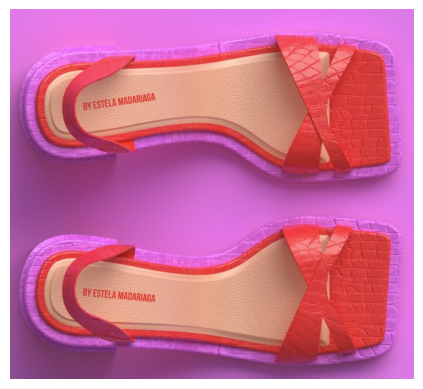

In [7]:
### Query the collection
results = collection.query(
    query_texts=["Show me sandals"], # Chroma will embed this for you
    include=['data'], 
    n_results=1 # how many results to return
)
for img in results['data'][0]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()

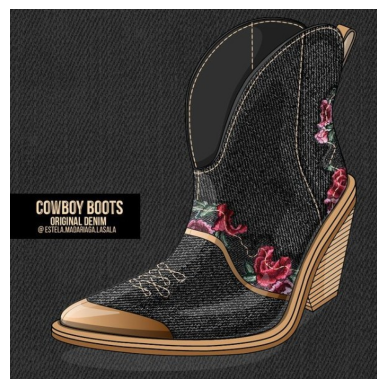

In [8]:
### Query the collection
results = collection.query(
    query_texts=["Show me a pair of cowboy boots"], # Chroma will embed this for you
    include=['data'], 
    n_results=1 # how many results to return
)
for img in results['data'][0]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()

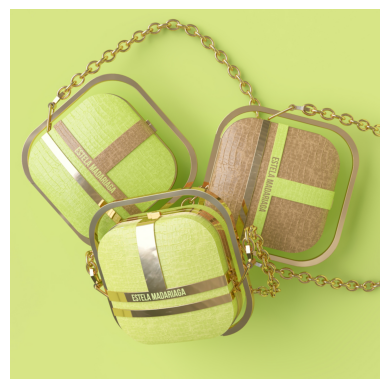

In [9]:
### Query the collection
results = collection.query(
    query_texts=["Show me a bags"], # Chroma will embed this for you
    include=['data'], 
    n_results=1 # how many results to return
)
for img in results['data'][0]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()

* `Caso 2`: Consultar la coleccion de imágenes utilizando imagenes.

Input data: Imagen de una sandalia no incluida en la base de datos vectorial

In [11]:
TEST_IMAGE_FOLDER = "../tests/images"

(310, 377, 3)
Query Image


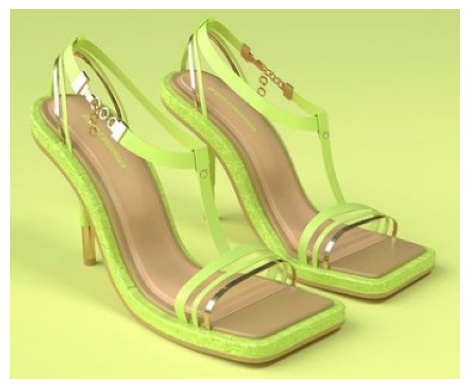

In [12]:
# load image and convert to numpy array
query_image = np.array(Image.open(f"{TEST_IMAGE_FOLDER}/12.jpg"))
print(query_image.shape)
print("Query Image")
plt.imshow(query_image)
plt.axis('off')
plt.show()

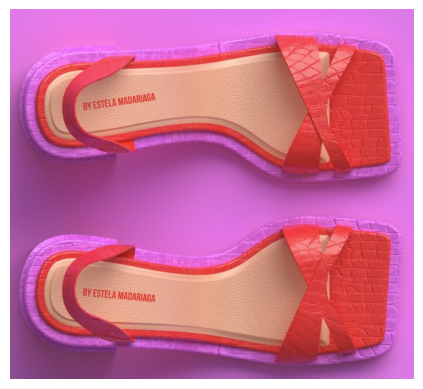

In [13]:
# Use query_image function to query the collection 
results = collection.query(query_images=[query_image], include=['data'], n_results=1)
for img in results['data'][0]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Input data: Imagen de una bota no incluida en la base de datos vectorial

(731, 717, 3)
Query Image


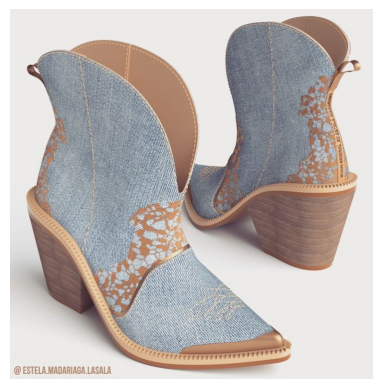

In [14]:
# load image and convert to numpy array
query_image = np.array(Image.open(f"{TEST_IMAGE_FOLDER}/15.jpg"))
print(query_image.shape)
print("Query Image")
plt.imshow(query_image)
plt.axis('off')
plt.show()

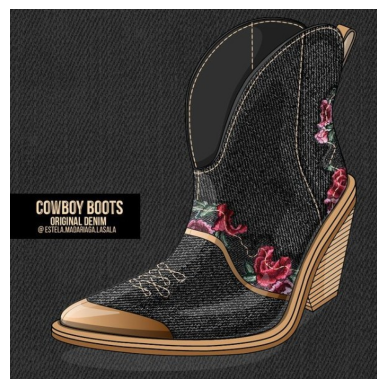

In [15]:
# Use query_image function to query the collection 
results = collection.query(query_images=[query_image], include=['data'], n_results=1)
for img in results['data'][0]:
    plt.imshow(img)
    plt.axis("off")
    plt.show()